In [1]:
import torch
import importlib
import numpy as np
import pandas as pd
import torch.nn as nn
from PIL import Image
from cellsmap.util import io
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn import decomposition as skdecomp
import matplotlib.pyplot as plt

from cellsmap.analyses.playground import const, trans, dataset, pipeline, arch, trainer, proc

import ae, ae_eval

In [2]:
importlib.reload(ae)
importlib.reload(ae_eval)

<module 'ae_eval' from '/allen/aics/assay-dev/MicroscopyOtherData/Viana/projects/cellsmap/cellsmap/analyses/playground/ae_eval.py'>

In [3]:
model_name = "3e76ebd3" #20b2f3a6
model = arch.BetaVAE(latent_dim=const.N)
model.load_state_dict(torch.load(f".output/{model_name}/weight.pth"))
_ = model.eval()

In [4]:
def get_vae_latent_variables(model, dataloader):
    model.eval()
    latent_vars = []
    with torch.no_grad():
        for batch_data in dataloader:
            mu, logvar = model.encode(batch_data)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std
            latent_vars.append(z)
    return torch.cat(latent_vars, dim=0)

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

reps = []
df = pd.DataFrame([])
timepoints_eval = [5, 500]
for t in timepoints_eval:
    reader = io.load_dataset("20240305_T01_001", channels=["CDH5_Tubulin", "Nuc_Seg"], time_start=t, time_end=t, level=2)
    zarr_dataset = dataset.ZARRDatasetEval(reader=reader, crop_size=const.M, transform=transform)
    loader = DataLoader(zarr_dataset, batch_size=64, shuffle=False)
    latent_vars = get_vae_latent_variables(model, loader)
    latent_vars = latent_vars.squeeze(-1).squeeze(-1)
    xc, yc = zarr_dataset.get_crop_coordinates()
    mean_int, max_int = zarr_dataset.get_crop_intensity_properties()
    df_tmp = pd.DataFrame(list(zip(xc, yc, mean_int, max_int, [t]*len(xc))), columns=["x", "y", "mean_int", "max_int", "time"])
    df = pd.concat([df, df_tmp], ignore_index=True)
    reps.append(latent_vars.numpy())
reps = np.concatenate(reps)

Dataset ready! Shape: (611, 64, 64)
Dataset ready! Shape: (642, 64, 64)


In [6]:
reps.shape

(1253, 256)

In [7]:
ndims = 2
pca = skdecomp.PCA(n_components=ndims)
latent_vars_pca = pca.fit_transform(reps)
for nd in range(ndims):
    df[f"pc{nd+1}"] = latent_vars_pca[:, nd]
df.head()

,x,y,mean_int,max_int,time,pc1,pc2
0,1090,186,114.204602,153.295911,5,-1.090701,-0.011309
1,1096,107,113.832600,155.290547,5,0.555213,-0.083959
2,1131,132,113.622241,149.715266,5,0.389297,-1.675269
3,1042,180,115.334752,265.873089,5,1.064303,1.173376
4,1059,217,114.870843,265.873089,5,-2.011500,-0.653004


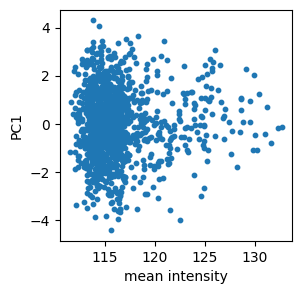

In [8]:
fig, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(df.mean_int, df.pc1, s=10)
ax.set_xlabel("mean intensity")
ax.set_ylabel("PC1")
plt.show()

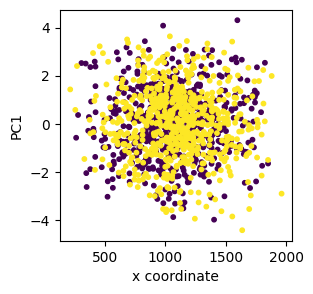

In [9]:
fig, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(df.x, df.pc1, c=df.time, s=10)
ax.set_xlabel("x coordinate")
ax.set_ylabel("PC1")
plt.show()

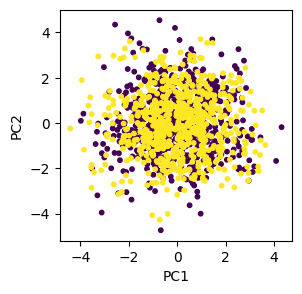

In [10]:
fig, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(df.pc1, df.pc2, c=df.time, s=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

In [11]:
# xi, yi = 1014-32, 286-32 #t = 0
xi, yi = 892-32, 270-32 #t = 563
# xi, yi = 1021-32, 255-32 #t = 563 Tubulin
# xi, yi = 824-32, 330-32 #t = 10 Tubulin
reader = io.load_dataset("20240305_T01_001", channels=["CDH5_Tubulin", "Nuc_Seg"], time_start=563, time_end=564, level=2)
crops = []
for c in range(reader.shape[0]):
    crop = reader[c].compute()[0][yi:yi+64, xi:xi+64]
    crop = proc.normalize_crop(crop, global_norm=False)
    crops.append(crop)

In [12]:
class PairImageDataset(Dataset):
    def __init__(self, data):
        self.data = [im.float() for im in data]
    def __len__(self):
        return 2
    def __getitem__(self, idx):
        return self.data[idx]
data = [torch.from_numpy(im).unsqueeze(0) for im in crops]
pair_dataset = PairImageDataset(data)
pair_loader = DataLoader(pair_dataset, batch_size=2)
latent_variables = get_vae_latent_variables(model, pair_loader)
latent_variables = latent_variables.squeeze(-1).squeeze(-1).numpy()

In [13]:
with torch.no_grad():
    reconstructions, _, _ = model(torch.concat([d.unsqueeze(0).float() for d in data]))
reconstructions = reconstructions.numpy().squeeze()

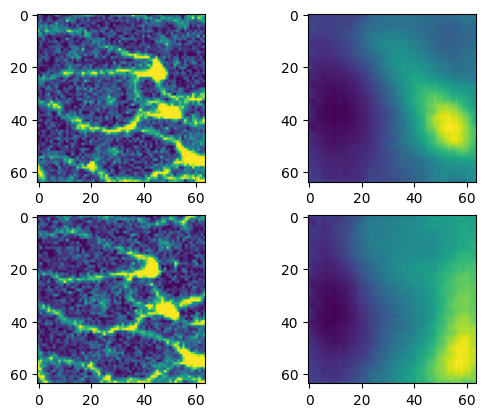

In [14]:
fig, axs = plt.subplots(2,2)
axs[0,0].imshow(crops[0])
axs[0,1].imshow(reconstructions[0])
axs[1,0].imshow(crops[1])
axs[1,1].imshow(reconstructions[1])
plt.show()

In [15]:
latent_variables.shape

(2, 256)

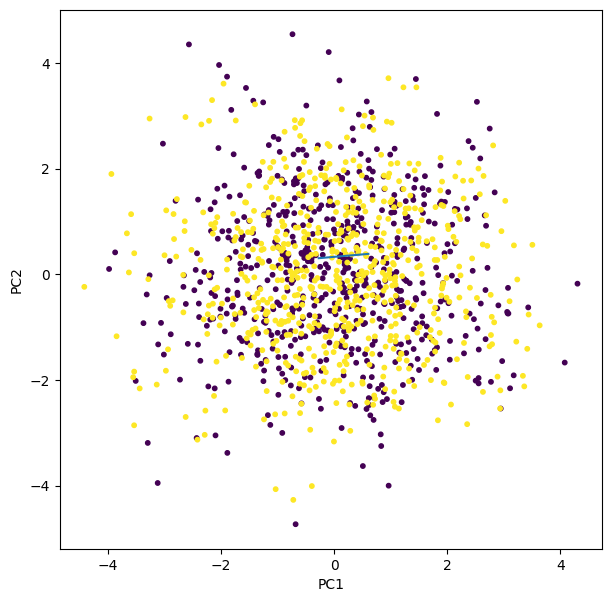

In [16]:
pcs = []
fig, ax = plt.subplots(1,1, figsize=(7,7))
xc, yc = zarr_dataset.get_crop_coordinates()
ax.scatter(df.pc1, df.pc2, c=df.time, s=10)
for rep in latent_variables:
    pcs.append(pca.transform(rep.reshape(1,-1))[0])
ax.plot([pcs[0][0],pcs[1][0]], [pcs[0][1],pcs[1][1]])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

In [17]:
reader = io.load_dataset("20240305_T01_001", channels=["CDH5_Tubulin", "Nuc_Seg"], time_start=0, level=2)
delta_dataset = dataset.DeltaDataset(reader=reader, crop_size=const.M, transform=transform)
print(delta_dataset.data.shape)

Dataset ready!
(5760, 64, 64)


In [18]:
loader = DataLoader(delta_dataset, batch_size=128)
lv = get_vae_latent_variables(model, loader)
lv = lv.squeeze(-1).squeeze(-1).numpy()

In [19]:
vecs = pca.transform(lv)

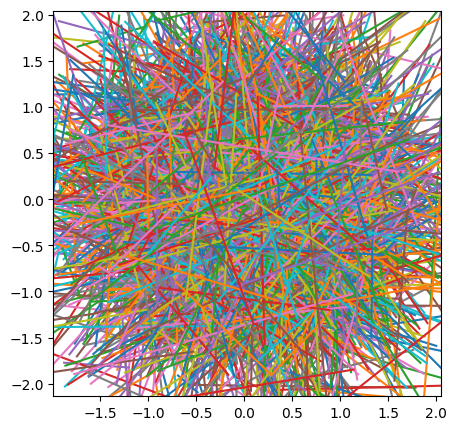

In [20]:
xmin, xmax = np.percentile(vecs[:,0], [2,98])
ymin, ymax = np.percentile(vecs[:,1], [2,98])
fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot([vecs[::2,0],vecs[1::2,0]], [vecs[::2,1],vecs[1::2,1]])
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.show()

In [21]:
df_pair = pd.DataFrame([])
tc, xc, yc = delta_dataset.get_crop_coordinates()
imean, imax = delta_dataset.get_crop_intensity_properties()
for colname, col in zip([
    "time",
    "x",
    "y", 
    "imean",
    "imax",
    "pc1",
    "pc2",
    "delta"], [
    tc,
    xc,
    yc,
    imean,
    imax,
    vecs[:,0],
    vecs[:,1],
    [0, 1]*int(0.5*len(xc))]):
    df_pair[colname] = col

In [22]:
df_pair.tail()

,time,x,y,imean,imax,pc1,pc2,delta
5755,576,1037,319,117.227476,196.178735,1.700511,1.612184,1
5756,575,1059,297,116.491300,200.550822,-0.057155,0.093949,0
5757,576,1059,297,116.726503,196.178735,1.296074,-0.834630,1
5758,575,1002,95,116.249182,171.506367,-0.342468,0.239562,0
5759,576,1002,95,116.227589,170.208056,-0.997209,-0.588953,1


In [23]:
# Apply threshold empirically determined. A better
# choice would be a time dependent threshold.
df2 = df_pair.query("imean < 120 and delta==0")
df2 = pd.concat([df2, df_pair.loc[1 + df2.index]])
print(df_pair.shape, df2.shape)

(5760, 8) (5168, 8)


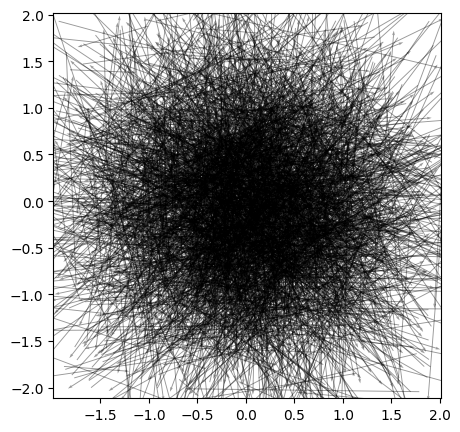

In [24]:
offset = 2
xmin, xmax = np.percentile(df2.pc1, [offset, 100-offset])
ymin, ymax = np.percentile(df2.pc2, [offset, 100-offset])
fig, ax = plt.subplots(1, 1, figsize=(5,5))
xi, xf = df2.query("delta==0").pc1.values, df2.query("delta==1").pc1.values
yi, yf = df2.query("delta==0").pc2.values, df2.query("delta==1").pc2.values
valids = df2.query
ax.quiver(xi, yi, xf - xi, yf - yi, angles='xy', scale_units='xy', scale=1, alpha=0.4)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.show()

In [25]:
df_track = pd.DataFrame([[1462.801,441.792,1],
[1461.222,447.513,2],
[1459.343,452.322,3],
[1454.450,455.720,4],
[1451.588,459.819,5],
[1449.825,463.029,6],
[1448.281,466.303,7],
[1447.065,468.874,8],
[1449.236,470.743,9],
[1449.284,473.433,60],
[1453.067,478.834,61],
[1455.250,481.162,62],
[1459.885,489.557,63],
[1463.435,495.353,64],
[1466.935,501.306,65],
[1470.867,504.216,66],
[1481.329,512.060,67],
[1489.622,518.425,68],
[1495.827,523.821,69],
[1501.602,530.547,60],], columns=["xc", "yc", "time"])

In [26]:
crops_track = []
for index, row in df_track.iterrows():
    xi = int(row.xc/1.5280000-0.5*const.M)
    yi = int(row.yc/1.5280000-0.5*const.M)
    crop = reader[int(row.time-1)].compute()[0][yi:yi+const.M, xi:xi+const.M]
    crop = proc.normalize_crop(crop, global_norm=False)
    crops_track.append(crop)
    
class TrackDataset(Dataset):
    def __init__(self, data):
        self.data = [im.float() for im in data]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

data = [torch.from_numpy(im).unsqueeze(0) for im in crops_track]
track_dataset = TrackDataset(data)
track_loader = DataLoader(track_dataset, batch_size=len(df_track))
latent_variables = get_vae_latent_variables(model, track_loader)
latent_variables = latent_variables.squeeze(-1).squeeze(-1).numpy()

In [27]:
vecs = pca.transform(latent_variables)

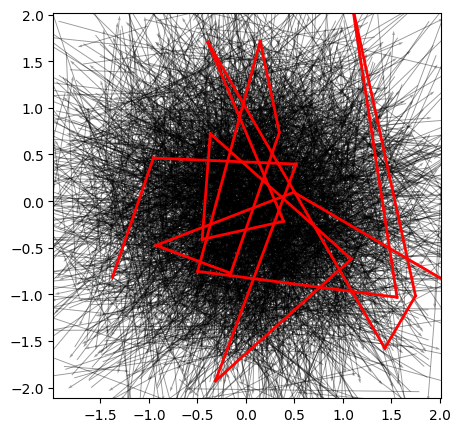

In [28]:
offset = 2
xmin, xmax = np.percentile(df2.pc1, [offset, 100-offset])
ymin, ymax = np.percentile(df2.pc2, [offset, 100-offset])
fig, ax = plt.subplots(1, 1, figsize=(5,5))
xi, xf = df2.query("delta==0").pc1.values, df2.query("delta==1").pc1.values
yi, yf = df2.query("delta==0").pc2.values, df2.query("delta==1").pc2.values
valids = df2.query
ax.quiver(xi, yi, xf - xi, yf - yi, angles='xy', scale_units='xy', scale=1, alpha=0.4)
for pcsi, pcsj in zip(vecs[:-1], vecs[1:]):
    ax.plot([pcsi[0], pcsj[0]], [pcsi[1], pcsj[1]], color="red", lw=2)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.show()

torch.Size([8, 256])


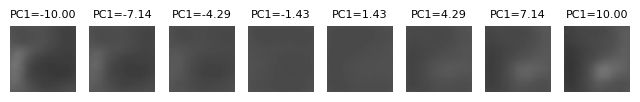

In [29]:
pcs = np.array([[u, 0] for u in np.linspace(-10.0, 10.0, 8)])
lvs = pca.inverse_transform(pcs)
data = torch.tensor(lvs, dtype=torch.float32)#.to('cuda' if torch.cuda.is_available() else 'cpu')
print(data.shape)

with torch.no_grad():
    reconstructions = model.decode(data).numpy().squeeze()

fig, axs = plt.subplots(1, len(pcs), figsize=(1*len(pcs), 1))
for ax, rec, v in zip(axs, reconstructions, pcs[:,0]):
    ax.imshow(rec, vmin=0, vmax=1, cmap="gray")
    ax.set_title(f"PC1={v:.2f}", fontsize=8)
    ax.axis("off")
plt.show()

torch.Size([8, 256])


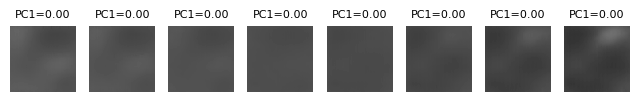

In [30]:
pcs = np.array([[0, u] for u in np.linspace(-10.0, 10.0, 8)])
lvs = pca.inverse_transform(pcs)
data = torch.tensor(lvs, dtype=torch.float32)
print(data.shape)

with torch.no_grad():
    reconstructions = model.decode(data).numpy().squeeze()

fig, axs = plt.subplots(1, len(pcs), figsize=(1*len(pcs), 1))
for ax, rec, v in zip(axs, reconstructions, pcs[:,0]):
    ax.imshow(rec, vmin=0, vmax=1, cmap="gray")
    ax.set_title(f"PC1={v:.2f}", fontsize=8)
    ax.axis("off")
plt.show()